# 📝 Text Summarisation Tool — Graded Assignment

**Gudsky Research Foundation · Research Intake 2026 · Day 21**
*Module: Transformers & LLMs — Advanced Text Generation Using GPT & LLaMA*

This notebook implements the end-to-end text summarisation pipeline required for the Day 21 graded assignment:

1. **Extractive summariser** — TextRank (graph-based, unsupervised)
2. **Abstractive summariser** — fine-tuned BART (`facebook/bart-large-cnn`)
3. **Evaluation** — ROUGE-1, ROUGE-2, ROUGE-L, and BERTScore on the CNN/DailyMail test set
4. **Web interface** — a Gradio demo comparing both summarisers on 5 news articles

> **Before running:** in Colab, go to `Runtime → Change runtime type → Hardware accelerator → T4 GPU`.
> Everything below is sized to run comfortably within a free-tier T4 (16 GB VRAM, limited session length).


## 1 · Setup

In [1]:
# Confirm we have a T4 (or any) GPU attached
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✅ GPU available: {torch.cuda.get_device_name(0)}")
    print(f"   CUDA capability: {torch.cuda.get_device_capability(0)}")
    print(f"   Total VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    device = torch.device("cpu")
    print("⚠️  No GPU detected — go to Runtime → Change runtime type → T4 GPU, then re-run this cell.")


✅ GPU available: Tesla T4
   CUDA capability: (7, 5)
   Total VRAM: 15.6 GB


In [2]:
# Pin huggingface_hub below 1.0 — the 1.x line has breaking changes (removed HfFolder, new
# internals) that transformers/gradio aren't fully compatible with yet, and at least one recent
# 1.x release shipped with a packaging bug that causes exactly this DeviceCodeError import crash.
!pip uninstall -y -q huggingface_hub
!pip install -q --force-reinstall "huggingface_hub>=0.34.0,<1.0"
!pip install -q -U transformers datasets accelerate sentencepiece
!pip install -q rouge_score bert_score
!pip install -q networkx scikit-learn nltk
!pip install -q -U gradio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 11.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
datasets 5.0.0 requires fsspec[http]<=2026.4.0,>=2023.1.0, but you have fsspec 2026.6.0 which is incompatible.
transformers 5.12.1 requires huggingface-hub<2.0,>=1.5.0, but you have huggingface-hub 0.36.2 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is i

In [3]:
import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)  # newer NLTK versions split this out separately

import re
import time
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod
from tqdm.auto import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from datasets import load_dataset
from transformers import BartForConditionalGeneration, BartTokenizer
from rouge_score import rouge_scorer
from bert_score import score as bertscore

import warnings
warnings.filterwarnings("ignore")

print("All imports successful.")


All imports successful.


## 2 · Load the CNN/DailyMail Dataset

We use the standard `cnn_dailymail` test split (3.0.0) so ROUGE/BERTScore numbers are comparable to
published baselines (Day 21 compendium, Section 7.3).

`EVAL_SIZE` controls how many test examples are used for the evaluation loop in Section 5. The
full test split has 11,490 examples — abstractive generation with beam search over the *full* set
will comfortably exceed a free Colab T4 session. Start small (`EVAL_SIZE = 50–100`) to validate the
pipeline, then raise it for your final submission numbers (run unattended, or in smaller batches).


In [4]:
EVAL_SIZE = 100   # ⬅️ increase for your final submission (e.g. 300–500+), keep small while testing

# Load from the namespaced, fully-Parquet repo (no loading script needed).
# Falls back to direct Parquet URLs if the Hub lookup itself has issues.
try:
    dataset = load_dataset("abisee/cnn_dailymail", "3.0.0")
except Exception as e:
    print(f"⚠️  load_dataset('abisee/cnn_dailymail', ...) failed ({type(e).__name__}: {e})")
    print("    Falling back to loading the Parquet files directly by URL...")
    base_url = "https://huggingface.co/datasets/abisee/cnn_dailymail/resolve/main/3.0.0/"
    data_files = {
        "train": [base_url + f"train-0000{i}-of-00003.parquet" for i in range(3)],
        "validation": base_url + "validation-00000-of-00001.parquet",
        "test": base_url + "test-00000-of-00001.parquet",
    }
    dataset = load_dataset("parquet", data_files=data_files)

test_subset = dataset["test"].select(range(EVAL_SIZE))

print(dataset)
print(f"\nUsing {len(test_subset)} test examples for evaluation.")
print("\n--- Sample article (truncated) ---")
print(test_subset[0]["article"][:500] + "...")
print("\n--- Reference summary ---")
print(test_subset[0]["highlights"])

DatasetDict({
    train: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 287113
    })
    validation: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 13368
    })
    test: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 11490
    })
})

Using 100 test examples for evaluation.

--- Sample article (truncated) ---
(CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the court is based. The Palestinians signed the ICC's founding Rome Statute in January, when they also accepted its jurisdiction over alleged crimes committed "in the occupied Palestinian territory, includin...

--- Reference summary ---
Membership gives the ICC jurisdiction over alleged crimes com

## 3 · Common Summariser Interface

Both summarisers implement the same interface (Day 21 compendium, Section A.1), so they can be
evaluated and compared under identical conditions.


In [5]:
class Summarizer(ABC):
    '''Common interface implemented by both the extractive and abstractive summarisers.'''

    @abstractmethod
    def summarize(self, article_text: str, max_sentences: int = 3, max_length: int = 130) -> str:
        raise NotImplementedError

    @property
    @abstractmethod
    def name(self) -> str:
        raise NotImplementedError


## 4 · Extractive Summariser — TextRank

Graph-based, unsupervised (Day 21 compendium, Section 6.1):

1. Split the article into sentences.
2. Build a sentence-similarity graph using TF-IDF cosine similarity as edge weights.
3. Run PageRank over that graph to score each sentence's centrality/importance.
4. Return the top-N highest-scoring sentences, **re-ordered to match their original position**
   in the article (so the summary reads coherently, not in rank order).

This runs on CPU — no GPU needed — and is intentionally dependency-light (no transformer model).


In [6]:
class TextRankSummarizer(Summarizer):
    @property
    def name(self) -> str:
        return "Extractive (TextRank)"

    def _split_sentences(self, text: str):
        sentences = nltk.sent_tokenize(text)
        # Filter out very short "sentences" (artifacts, datelines, etc.)
        return [s.strip() for s in sentences if len(s.strip().split()) > 3]

    def summarize(self, article_text: str, max_sentences: int = 3, max_length: int = 130) -> str:
        sentences = self._split_sentences(article_text)
        if len(sentences) <= max_sentences:
            return " ".join(sentences)

        # TF-IDF similarity graph
        vectorizer = TfidfVectorizer(stop_words="english")
        try:
            tfidf_matrix = vectorizer.fit_transform(sentences)
        except ValueError:
            # Degenerate case: e.g. all-stopword sentences
            return " ".join(sentences[:max_sentences])

        similarity_matrix = cosine_similarity(tfidf_matrix)
        np.fill_diagonal(similarity_matrix, 0)  # a sentence isn't its own neighbour

        graph = nx.from_numpy_array(similarity_matrix)
        scores = nx.pagerank(graph, max_iter=200)

        ranked_idx = sorted(scores, key=scores.get, reverse=True)[:max_sentences]
        ranked_idx_in_order = sorted(ranked_idx)  # restore original article order

        summary = " ".join(sentences[i] for i in ranked_idx_in_order)
        return summary


extractive_summarizer = TextRankSummarizer()

# Quick smoke test
sample_article = test_subset[0]["article"]
print("--- TextRank summary ---")
print(extractive_summarizer.summarize(sample_article, max_sentences=3))


--- TextRank summary ---
(CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. "As Palestine formally becomes a State Party to the Rome Statute today, the world is also a step closer to ending a long era of impunity and injustice," he said, according to an ICC news release. "As we have said repeatedly, we do not believe that Palestine is a state and therefore we do not believe that it is eligible to join the ICC," the State Department said in a statement.


## 5 · Abstractive Summariser — BART

`facebook/bart-large-cnn` is BART (Day 21 compendium, Section 6.2) **already fine-tuned on
CNN/DailyMail** — this satisfies the assignment's "fine-tuned BART or T5" requirement directly,
following the transfer-learning principle from Day 20: reuse a strong fine-tuned checkpoint rather
than retrain from scratch when one is already available for your exact target distribution.

Decoding uses beam search (`num_beams=4`), matching the compendium's recommendation that
summarisation — unlike open-ended creative generation — benefits from beam search's tendency to
converge on a broadly-agreed, high-probability sequence (Section 6.4).

An **optional** fine-tuning cell is provided further down for those who want to additionally
fine-tune on a custom subset — clearly marked, since it is not required to satisfy the assignment.


In [7]:
BART_MODEL_NAME = "facebook/bart-large-cnn"

bart_tokenizer = BartTokenizer.from_pretrained(BART_MODEL_NAME)
bart_model = BartForConditionalGeneration.from_pretrained(BART_MODEL_NAME).to(device)
bart_model.eval()

print(f"Loaded {BART_MODEL_NAME} on {device}.")
print(f"Parameters: {sum(p.numel() for p in bart_model.parameters()) / 1e6:.0f}M")


[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

Loaded facebook/bart-large-cnn on cuda.
Parameters: 406M


In [8]:
class AbstractiveSummarizer(Summarizer):
    def __init__(self, model, tokenizer, device):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device

    @property
    def name(self) -> str:
        return "Abstractive (BART)"

    @torch.no_grad()
    def summarize(self, article_text: str, max_sentences: int = None, max_length: int = 130) -> str:
        inputs = self.tokenizer(
            article_text, max_length=1024, truncation=True, return_tensors="pt"
        ).to(self.device)

        summary_ids = self.model.generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            num_beams=4,            # beam search — see Day 21, Section 3.1 and 6.4
            max_length=max_length,
            min_length=30,
            length_penalty=2.0,     # discourages overly short summaries
            no_repeat_ngram_size=3, # mitigates repetition (Day 21, Section 3.4)
            early_stopping=True,
        )
        return self.tokenizer.decode(summary_ids[0], skip_special_tokens=True)


abstractive_summarizer = AbstractiveSummarizer(bart_model, bart_tokenizer, device)

# Quick smoke test on the same article used above
print("--- BART summary ---")
print(abstractive_summarizer.summarize(sample_article))
print("\n--- Reference summary ---")
print(test_subset[0]["highlights"])


--- BART summary ---
The Palestinian Authority becomes the 123rd member of the International Criminal Court. The move gives the court jurisdiction over alleged crimes in Palestinian territories. Israel and the United States opposed the Palestinians' efforts to join the body.

--- Reference summary ---
Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June .
Israel and the United States opposed the move, which could open the door to war crimes investigations against Israelis .


### 5.1 · (Optional) Further Fine-Tuning on a Custom Subset

Not required for the assignment — `bart-large-cnn` is already fine-tuned on CNN/DailyMail. This
cell is provided for those who want to see the fine-tuning loop itself (Day 20, Section 3), e.g. to
adapt the model to a different summarisation domain. It is **disabled by default**
(`RUN_FINETUNING = False`) since it adds significant runtime on a free T4.

If you do enable it, note the small `per_device_train_batch_size` and `fp16=True` — `bart-large` at
~400M parameters is memory-hungry on a 16GB T4, especially with optimiser states (Day 20, Section 2).


In [9]:
RUN_FINETUNING = False  # ⬅️ set True only if you want to demonstrate further fine-tuning

if RUN_FINETUNING:
    from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments, DataCollatorForSeq2Seq

    train_subset = dataset["train"].select(range(2000))   # small subset — keep T4 runtime reasonable
    val_subset = dataset["validation"].select(range(200))

    def preprocess(batch):
        model_inputs = bart_tokenizer(
            batch["article"], max_length=1024, truncation=True
        )
        labels = bart_tokenizer(
            batch["highlights"], max_length=130, truncation=True
        )
        model_inputs["labels"] = labels["input_ids"]
        return model_inputs

    tokenized_train = train_subset.map(preprocess, batched=True, remove_columns=train_subset.column_names)
    tokenized_val = val_subset.map(preprocess, batched=True, remove_columns=val_subset.column_names)

    data_collator = DataCollatorForSeq2Seq(bart_tokenizer, model=bart_model)

    training_args = Seq2SeqTrainingArguments(
        output_dir="./bart-finetuned",
        per_device_train_batch_size=2,      # small — bart-large is memory-hungry on a T4
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=4,
        learning_rate=2e-5,                 # Day 20, Section 4 — conservative LR for fine-tuning
        num_train_epochs=1,
        fp16=True,                          # mixed precision — fits more comfortably on a T4
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_steps=50,
        predict_with_generate=True,
    )

    trainer = Seq2SeqTrainer(
        model=bart_model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
        data_collator=data_collator,
        tokenizer=bart_tokenizer,
    )

    trainer.train()
    print("Fine-tuning complete. bart_model has been updated in place.")
else:
    print("Skipping optional fine-tuning (RUN_FINETUNING = False). Using facebook/bart-large-cnn as-is.")


Skipping optional fine-tuning (RUN_FINETUNING = False). Using facebook/bart-large-cnn as-is.


## 6 · Evaluation — ROUGE-1, ROUGE-2, ROUGE-L, and BERTScore

Per the Day 21 compendium (Section 7.3), no single metric tells the whole story — we compute and
report **all four** metrics for both summarisers, on identical examples, so the comparison is fair.

BERTScore is computed in a single batched call per summariser (much faster than per-example calls).


In [10]:
rouge_calc = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

def evaluate_summarizer(summarizer: Summarizer, examples, max_sentences=3, max_length=130, desc=None):
    '''Generates summaries for every example and computes ROUGE-1/2/L + BERTScore.'''
    generated, references = [], []

    for ex in tqdm(examples, desc=desc or summarizer.name):
        article, reference = ex["article"], ex["highlights"]
        try:
            summary = summarizer.summarize(article, max_sentences=max_sentences, max_length=max_length)
        except Exception as e:
            summary = ""  # keep the loop alive on a malformed example rather than crashing the run
            print(f"⚠️  Skipped one example due to: {e}")
        generated.append(summary)
        references.append(reference)

    # ROUGE — averaged per-example F1
    rouge1_f, rouge2_f, rougeL_f = [], [], []
    for gen, ref in zip(generated, references):
        scores = rouge_calc.score(ref, gen)
        rouge1_f.append(scores["rouge1"].fmeasure)
        rouge2_f.append(scores["rouge2"].fmeasure)
        rougeL_f.append(scores["rougeL"].fmeasure)

    # BERTScore — single batched call
    _, _, bert_f1 = bertscore(generated, references, lang="en", verbose=False)

    return {
        "Summariser": summarizer.name,
        "ROUGE-1": np.mean(rouge1_f),
        "ROUGE-2": np.mean(rouge2_f),
        "ROUGE-L": np.mean(rougeL_f),
        "BERTScore": bert_f1.mean().item(),
    }, generated, references


In [11]:
# Run evaluation for both summarisers over the same `test_subset` (defined in Section 2)
extractive_results, extractive_gen, refs = evaluate_summarizer(
    extractive_summarizer, test_subset, max_sentences=3
)
abstractive_results, abstractive_gen, _ = evaluate_summarizer(
    abstractive_summarizer, test_subset, max_length=130
)

results_df = pd.DataFrame([extractive_results, abstractive_results]).set_index("Summariser")
results_df.round(4)


Extractive (TextRank):   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Abstractive (BART):   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,ROUGE-1,ROUGE-2,ROUGE-L,BERTScore
Summariser,,,,
Extractive (TextRank),0.2901,0.1054,0.1987,0.8618
Abstractive (BART),0.3684,0.1644,0.2765,0.8795


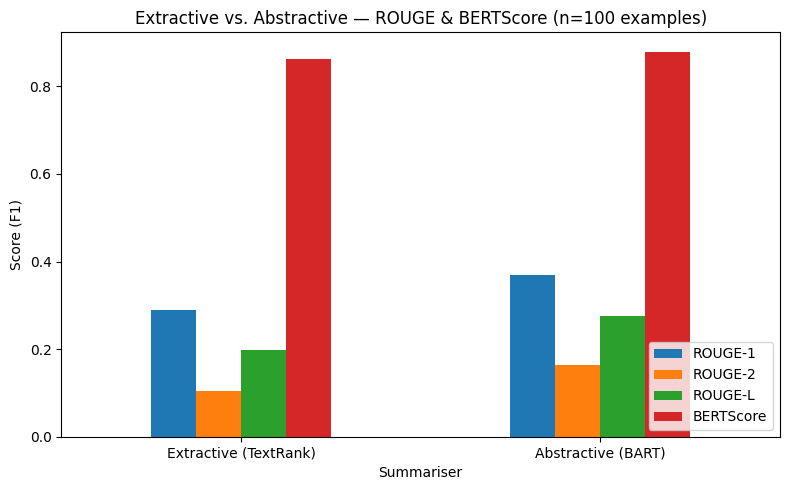

In [12]:
# Visualise the comparison
ax = results_df.plot(kind="bar", figsize=(8, 5), rot=0)
ax.set_ylabel("Score (F1)")
ax.set_title(f"Extractive vs. Abstractive — ROUGE & BERTScore (n={len(test_subset)} examples)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("evaluation_comparison.png", dpi=150)
plt.show()


In [13]:
# Save full results for your submission write-up
results_df.to_csv("evaluation_results.csv")
print("Saved evaluation_results.csv and evaluation_comparison.png")
results_df


Saved evaluation_results.csv and evaluation_comparison.png


,ROUGE-1,ROUGE-2,ROUGE-L,BERTScore
Summariser,,,,
Extractive (TextRank),0.290092,0.105378,0.198741,0.861812
Abstractive (BART),0.368384,0.164416,0.276507,0.879493


## 7 · Web Interface — Gradio Demo

A minimal interface (Day 21 compendium, Section A.1/A.3): paste or pick an article, choose a
summariser, see the output. Pre-loaded with **5 example articles** pulled from the test set —
swap in your own 5 choices by editing `EXAMPLE_INDICES` below.


In [14]:
import gradio as gr

EXAMPLE_INDICES = [0, 1, 2, 3, 4]   # ✅️ change these to pick different articles from test_subset

example_articles = [dataset["test"][i]["article"] for i in EXAMPLE_INDICES]

def summarize_with_choice(article_text: str, method: str) -> str:
    if not article_text or not article_text.strip():
        return "Please paste an article or choose an example below."
    if method == "Extractive (TextRank)":
        return extractive_summarizer.summarize(article_text, max_sentences=3)
    else:
        return abstractive_summarizer.summarize(article_text, max_length=130)


with gr.Blocks(title="Gudsky Text Summarisation Tool") as demo:
    gr.Markdown(
        "# 📝 Text Summarisation Tool\n"
        "**Gudsky Research Foundation · Day 21 Graded Assignment**\n\n"
        "Paste a news article (or pick an example below) and compare extractive vs. abstractive summarisation."
    )
    with gr.Row():
        with gr.Column():
            article_input = gr.Textbox(
                label="Article Text", lines=14, placeholder="Paste a news article here..."
            )
            method_choice = gr.Dropdown(
                choices=["Extractive (TextRank)", "Abstractive (BART)"],
                value="Abstractive (BART)",
                label="Summarisation Method",
            )
            run_button = gr.Button("Summarise", variant="primary")
        with gr.Column():
            summary_output = gr.Textbox(label="Generated Summary", lines=14)

    run_button.click(
        fn=summarize_with_choice, inputs=[article_input, method_choice], outputs=summary_output
    )

    gr.Examples(
        examples=[[a, "Abstractive (BART)"] for a in example_articles],
        inputs=[article_input, method_choice],
        label="5 Example Articles (from CNN/DailyMail test set)",
    )

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://57194e19bad9e2286d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 8 · Written Comparison (Starter)

The cell below auto-prints your measured metrics as a starting point. Replace the `TODO` text with
your own analysis — the rubric (Day 21 compendium, Section A.2) weights this at 15% combined with
code quality, and specifically rewards discussing **where the four metrics agree or disagree**
(Section 7.3).


In [15]:
print("=" * 60)
print(f"Results over {len(test_subset)} CNN/DailyMail test examples")
print("=" * 60)
print(results_df.round(4).to_string())
print()
print("TODO — replace with your own analysis. Prompts to address:")
print(" • Which summariser scored higher on each metric, and by how much?")
print(" • Did ROUGE and BERTScore agree on which summariser was better?")
print(" • Look at 2–3 individual examples where they disagreed — what happened?")
print(" • Which summariser would you recommend for a high factual-risk domain")
print("   (legal/medical), and why? (Day 21 compendium, Section 6.3)")


Results over 100 CNN/DailyMail test examples
                       ROUGE-1  ROUGE-2  ROUGE-L  BERTScore
Summariser                                                 
Extractive (TextRank)   0.2901   0.1054   0.1987     0.8618
Abstractive (BART)      0.3684   0.1644   0.2765     0.8795

TODO — replace with your own analysis. Prompts to address:
 • Which summariser scored higher on each metric, and by how much?
 • Did ROUGE and BERTScore agree on which summariser was better?
 • Look at 2–3 individual examples where they disagreed — what happened?
 • Which summariser would you recommend for a high factual-risk domain
   (legal/medical), and why? (Day 21 compendium, Section 6.3)


## 9 · Submission Checklist

- [ ] Extractive summariser implemented and producing output on sample articles
- [ ] Abstractive summariser implemented and producing output on sample articles
- [ ] ROUGE-1, ROUGE-2, ROUGE-L, and BERTScore computed for both, on the CNN/DailyMail test set
- [ ] `EVAL_SIZE` increased from the testing default before final submission numbers are generated
- [ ] Gradio interface running and demonstrated on 5 chosen news articles
- [ ] Written comparison completed in Section 8 (not left as `TODO`)
- [ ] Notebook runs top-to-bottom without errors on a fresh Colab T4 runtime (`Runtime → Restart and run all`)

---
*Gudsky Research Foundation · Research Intake 2026 · Day 21 · Transformers & LLMs*
